# Análisis de Factores Exploratorio — BabyFace Validation


## 1. Carga de librerías y configuración

El notebook usa solamente librerías estándar de análisis científico disponibles en Python: `pandas`, `numpy`, `scipy`, `scikit-learn` y `matplotlib`. Para el EFA se usa `sklearn.decomposition.FactorAnalysis` con rotación `varimax`.

In [ ]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from scipy import stats
from sklearn.decomposition import FactorAnalysis
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# Rutas: el notebook busca el Excel en la misma carpeta y, si no existe, en /mnt/data.
NOTEBOOK_DIR = Path.cwd()
CANDIDATE_PATHS = [
    NOTEBOOK_DIR / "DataFrameBabyFaceValidacion.xlsx",
    Path("/mnt/data/DataFrameBabyFaceValidacion.xlsx"),
]
DATA_PATH = next((p for p in CANDIDATE_PATHS if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("No se encontró DataFrameBabyFaceValidacion.xlsx en la carpeta del notebook ni en /mnt/data.")

OUTPUT_DIR = NOTEBOOK_DIR / "efa_babyface_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:0.4f}")

print(f"Base de datos: {DATA_PATH}")
print(f"Carpeta de salidas: {OUTPUT_DIR}")

Base de datos: /mnt/data/DataFrameBabyFaceValidacion.xlsx
Carpeta de salidas: /efa_babyface_outputs


## 2. Carga inicial de datos

In [ ]:
df_raw = pd.read_excel(DATA_PATH)
print(f"Dimensiones de la base original: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas")
display(df_raw.head())

display(pd.DataFrame({
    "columna": df_raw.columns,
    "tipo_original": [str(t) for t in df_raw.dtypes],
    "valores_no_nulos": [df_raw[c].notna().sum() for c in df_raw.columns],
    "valores_unicos": [df_raw[c].nunique(dropna=True) for c in df_raw.columns]
}))

Dimensiones de la base original: 366 filas x 27 columnas


,dia,t_total,t_prueba1,t_prueba2,rechaza,llora,toca,prueba,consume,valence_inicio,arousal_inicio,valence_p1_before,valence_p1_during,valence_p1_after,valence_p2_before,valence_p2_during,valence_p2_after,arousal_p1_before,arousal_p1_during,arousal_p1_after,arousal_p2_before,arousal_p2_during,arousal_p2_after,valence_final,arousal_final,comentarios,id
0,1,10.4600,1.1300,8.2000,0,0,0,1,1,0.0841,0.2255,0.0944,0.1023,0.1081,0.3721,0.3926,0.3910,0.2235,0.1959,0.3347,0.9243,0.9213,0.9128,0.3324,0.7401,NaN,ID1
1,2,15.3000,5.2200,11.3000,0,0,0,1,1,0.3909,0.9900,0.1844,0.1883,0.1648,0.2545,0.4234,0.4017,0.4035,0.3547,0.3431,0.4445,0.4445,0.5769,0.0884,0.8984,NaN,ID1
2,3,22.1600,1.3000,8.6300,0,0,0,1,1,0.0724,0.4942,0.2046,0.2114,0.1503,0.2319,0.1753,0.1532,0.5099,0.5866,0.6120,0.8740,0.8582,0.8285,0.0809,0.7748,NaN,ID1
3,4,24.3900,1.0300,10.1600,0,0,0,1,1,FIT_FAILED,FIT_FAILED,FIT_FAILED,FIT_FAILED,0.0957,0.3477,0.2666,0.2220,FIT_FAILED,FIT_FAILED,0.7446,0.5633,0.5442,0.5223,0.1145,0.6569,"Sólo lo consume la 1ra vez, 2da sólo pruba",ID1
4,5,30.0300,2.8600,11.2000,0,0,0,1,0,0.2773,0.4485,0.1709,0.1388,0.1257,0.1037,0.2232,0.2666,0.5601,0.6002,0.5646,0.6696,0.6344,0.6132,0.0696,0.7081,NaN,ID1


,columna,tipo_original,valores_no_nulos,valores_unicos
0,dia,object,366,69
1,t_total,object,365,336
2,t_prueba1,object,297,211
3,t_prueba2,object,186,160
4,rechaza,object,364,3
5,llora,object,363,3
6,toca,object,364,3
7,prueba,object,364,3
8,consume,object,364,3
9,valence_inicio,object,359,331


## 3. Limpieza y preparación

En la base aparecen valores como `FIT_FAILED`, `FIT FAILED`, `FIND_FAILED`, `NA`, `S/I` y `-`. Estos valores indican fallos de lectura o ausencia de información, por lo que se convierten a `NaN`.

Además:

- `id` se conserva como identificador del infante.
- `dia` se transforma en `dia_num` extrayendo el número del día cuando aparece con sufijos como `2E`, `4P`, etc.
- Las variables binarias se convierten a 0/1 cuando es posible.
- Las variables de tiempo se intentan convertir a segundos, aunque no se usan como indicadores principales del EFA.

In [ ]:
MISSING_TOKENS = {
    "FIT_FAILED", "FIT FAILED", "FIND_FAILED", "FIND FAILED", "NA", "NA ",
    "N/A", "S/I", "-", "", "nan", "NaN", "None"
}

ID_COL = "id"
TEXT_COL = "comentarios"
DAY_COL = "dia"
BEHAVIOR_COLS = ["rechaza", "llora", "toca", "prueba", "consume"]
TIME_COLS = ["t_total", "t_prueba1", "t_prueba2"]
AFFECT_COLS = [c for c in df_raw.columns if c.startswith("valence") or c.startswith("arousal")]


def normalize_missing_value(x):
    """Convierte strings de error o ausencia a NaN."""
    if pd.isna(x):
        return np.nan
    if isinstance(x, str):
        s = x.strip()
        if s in MISSING_TOKENS:
            return np.nan
    return x


def to_numeric_clean(s: pd.Series) -> pd.Series:
    """Convierte una serie a numérica después de limpiar tokens de error."""
    cleaned = s.map(normalize_missing_value)
    return pd.to_numeric(cleaned, errors="coerce")


def parse_day(x):
    """Extrae el número de día de valores como 1, 2E, 4P, etc."""
    x = normalize_missing_value(x)
    if pd.isna(x):
        return np.nan
    m = re.search(r"\d+", str(x))
    return float(m.group(0)) if m else np.nan


def parse_time_seconds(x):
    """Convierte duraciones flexibles a segundos.

    Soporta ejemplos como:
    - 10.46 -> 10.46 segundos
    - 00:00:02.200 -> 2.2 segundos
    - 1.00.60 -> 60.60 segundos, interpretado como min.seg.centésimas
    - 1,34,033 -> 94.033 segundos, interpretado como min,seg,milisegundos
    """
    x = normalize_missing_value(x)
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    s = str(x).strip()
    if s in MISSING_TOKENS:
        return np.nan

    # Formato HH:MM:SS.sss
    if ":" in s:
        parts = s.split(":")
        try:
            parts = [p.replace(",", ".") for p in parts]
            nums = [float(p) for p in parts]
            if len(nums) == 3:
                return nums[0] * 3600 + nums[1] * 60 + nums[2]
            if len(nums) == 2:
                return nums[0] * 60 + nums[1]
        except Exception:
            return np.nan

    # Formatos con múltiples separadores: 1.00.60 o 1,34,033
    if s.count(".") >= 2 or s.count(",") >= 2:
        parts = re.split(r"[\.,]", s)
        parts = [p for p in parts if p != ""]
        if len(parts) >= 3 and all(p.isdigit() for p in parts[:3]):
            minutes = float(parts[0])
            seconds = float(parts[1])
            frac = float("0." + parts[2])
            return minutes * 60 + seconds + frac

    # Número con coma decimal
    s2 = s.replace(",", ".")
    try:
        return float(s2)
    except Exception:
        return np.nan


# Construcción del dataframe limpio
clean = df_raw.copy()
clean["dia_num"] = df_raw[DAY_COL].map(parse_day)

for col in AFFECT_COLS + BEHAVIOR_COLS:
    clean[col] = to_numeric_clean(df_raw[col])

for col in TIME_COLS:
    clean[col + "_sec"] = df_raw[col].map(parse_time_seconds)

# Conservamos comentarios e id sin transformación agresiva
if ID_COL in clean.columns:
    clean[ID_COL] = clean[ID_COL].astype(str)

print("Columnas de afecto usadas potencialmente en EFA:")
print(AFFECT_COLS)
print("\nVariables conductuales usadas como validación externa:")
print(BEHAVIOR_COLS)

Columnas de afecto usadas potencialmente en EFA:
['valence_inicio', 'arousal_inicio', 'valence_p1_before', 'valence_p1_during', 'valence_p1_after', 'valence_p2_before', 'valence_p2_during', 'valence_p2_after', 'arousal_p1_before', 'arousal_p1_during', 'arousal_p1_after', 'arousal_p2_before', 'arousal_p2_during', 'arousal_p2_after', 'valence_final', 'arousal_final']

Variables conductuales usadas como validación externa:
['rechaza', 'llora', 'toca', 'prueba', 'consume']


## 4. Revisión de faltantes y selección de variables

Las columnas de segunda prueba (`p2`) tienen mayor porcentaje de faltantes. Por eso se proponen dos modelos:

- **Modelo principal/core:** incluye inicio, prueba 1 y final. Evita las columnas con más de 50% de faltantes.
- **Modelo ampliado/sensibilidad:** incluye también prueba 2. Es útil para explorar si la estructura se separa por prueba 1 vs. prueba 2, pero debe interpretarse con más cautela.

,variable,n_observado,n_faltante,pct_faltante,media,desv_est
15,arousal_final,345,21,5.7377,0.4571,0.2034
14,valence_final,345,21,5.7377,0.1813,0.1169
0,valence_inicio,330,36,9.8361,0.1936,0.1465
1,arousal_inicio,330,36,9.8361,0.3729,0.2928
3,valence_p1_during,276,90,24.5902,0.2221,0.1296
9,arousal_p1_during,276,90,24.5902,0.4985,0.2384
10,arousal_p1_after,272,94,25.6831,0.5065,0.2293
4,valence_p1_after,272,94,25.6831,0.2126,0.1217
8,arousal_p1_before,232,134,36.6120,0.5106,0.2333
2,valence_p1_before,232,134,36.6120,0.2314,0.1245


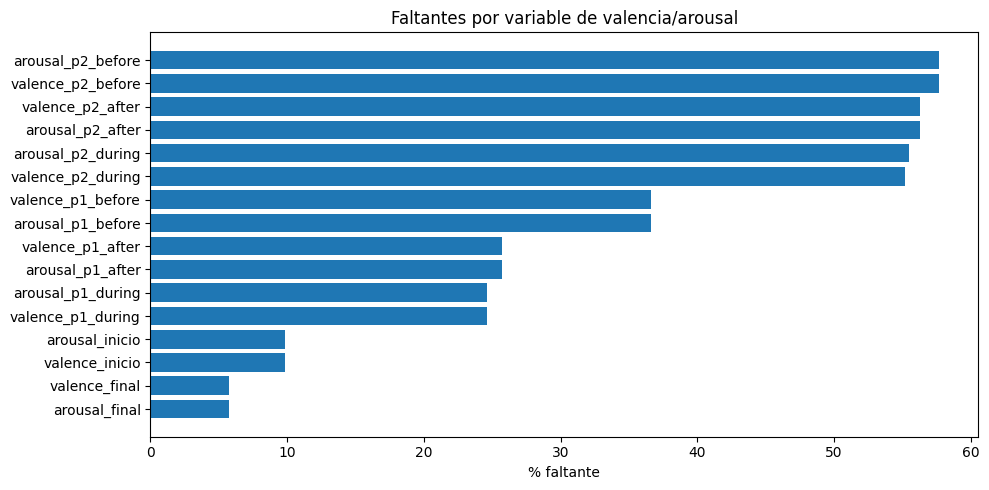

In [ ]:
def missing_table(data, cols):
    out = pd.DataFrame({
        "variable": cols,
        "n_observado": [data[c].notna().sum() for c in cols],
        "n_faltante": [data[c].isna().sum() for c in cols],
        "pct_faltante": [100 * data[c].isna().mean() for c in cols],
        "media": [data[c].mean() for c in cols],
        "desv_est": [data[c].std() for c in cols],
    })
    return out.sort_values("pct_faltante")

miss_affect = missing_table(clean, AFFECT_COLS)
display(miss_affect)
miss_affect.to_csv(OUTPUT_DIR / "missingness_affect_variables.csv", index=False)

plt.figure(figsize=(10, 5))
plt.barh(miss_affect["variable"], miss_affect["pct_faltante"])
plt.xlabel("% faltante")
plt.title("Faltantes por variable de valencia/arousal")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "faltantes_variables_afecto.png", dpi=160, bbox_inches="tight")
plt.show()

In [ ]:
CORE_AFFECT_COLS = [
    "valence_inicio", "arousal_inicio",
    "valence_p1_before", "arousal_p1_before",
    "valence_p1_during", "arousal_p1_during",
    "valence_p1_after", "arousal_p1_after",
    "valence_final", "arousal_final",
]

ALL_AFFECT_COLS = AFFECT_COLS.copy()

print(f"Modelo principal/core: {len(CORE_AFFECT_COLS)} variables")
print(CORE_AFFECT_COLS)
print(f"\nModelo ampliado/sensibilidad: {len(ALL_AFFECT_COLS)} variables")
print(ALL_AFFECT_COLS)

Modelo principal/core: 10 variables
['valence_inicio', 'arousal_inicio', 'valence_p1_before', 'arousal_p1_before', 'valence_p1_during', 'arousal_p1_during', 'valence_p1_after', 'arousal_p1_after', 'valence_final', 'arousal_final']

Modelo ampliado/sensibilidad: 16 variables
['valence_inicio', 'arousal_inicio', 'valence_p1_before', 'valence_p1_during', 'valence_p1_after', 'valence_p2_before', 'valence_p2_during', 'valence_p2_after', 'arousal_p1_before', 'arousal_p1_during', 'arousal_p1_after', 'arousal_p2_before', 'arousal_p2_during', 'arousal_p2_after', 'valence_final', 'arousal_final']


## 5. Funciones estadísticas para EFA

Se calculan tres elementos para decidir si el EFA es razonable:

- **KMO:** mide si la matriz de correlaciones es adecuada para análisis factorial. Valores cercanos o superiores a 0.70 suelen considerarse aceptables para exploración.
- **Bartlett:** prueba si la matriz de correlación difiere de la identidad. Un p-valor pequeño indica que hay correlaciones suficientes.
- **Scree plot, criterio de Kaiser y análisis paralelo:** ayudan a sugerir el número de factores.

In [ ]:
def prepare_matrix(data: pd.DataFrame, cols, imputation="median"):
    """Imputa y estandariza columnas para EFA."""
    X_raw = data[cols].copy()
    imputer = SimpleImputer(strategy=imputation)
    X_imp = imputer.fit_transform(X_raw)
    scaler = StandardScaler()
    X = scaler.fit_transform(X_imp)
    return X, imputer, scaler


def corr_matrix(X):
    R = np.corrcoef(X, rowvar=False)
    R = np.nan_to_num(R, nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(R, 1.0)
    return R


def kmo_statistic(R):
    """Calcula KMO global a partir de la matriz de correlación."""
    try:
        inv_R = np.linalg.inv(R)
    except np.linalg.LinAlgError:
        inv_R = np.linalg.pinv(R)
    d = np.sqrt(np.diag(inv_R))
    partial = -inv_R / np.outer(d, d)
    np.fill_diagonal(partial, 0.0)

    r2 = R.copy()
    np.fill_diagonal(r2, 0.0)
    numerator = np.sum(r2 ** 2)
    denominator = numerator + np.sum(partial ** 2)
    return numerator / denominator if denominator > 0 else np.nan


def bartlett_sphericity(R, n_obs):
    """Prueba de esfericidad de Bartlett."""
    p = R.shape[0]
    sign, logdet = np.linalg.slogdet(R)
    if sign <= 0:
        R_adj = R + np.eye(p) * 1e-6
        sign, logdet = np.linalg.slogdet(R_adj)
    chi2 = -(n_obs - 1 - (2 * p + 5) / 6) * logdet
    dof = p * (p - 1) / 2
    p_value = stats.chi2.sf(chi2, dof)
    return chi2, dof, p_value


def parallel_analysis(X, n_iter=500, random_state=42):
    """Análisis paralelo usando datos normales aleatorios con igual n y p."""
    rng = np.random.default_rng(random_state)
    n, p = X.shape
    eig_obs = np.linalg.eigvalsh(corr_matrix(X))[::-1]
    eig_sim = np.zeros((n_iter, p))
    for i in range(n_iter):
        Z = rng.normal(size=(n, p))
        Z = StandardScaler().fit_transform(Z)
        eig_sim[i, :] = np.linalg.eigvalsh(corr_matrix(Z))[::-1]
    eig_mean = eig_sim.mean(axis=0)
    eig_p95 = np.percentile(eig_sim, 95, axis=0)
    n_parallel = int(np.sum(eig_obs > eig_p95))
    return eig_obs, eig_mean, eig_p95, n_parallel


def plot_scree(eig_obs, eig_mean, eig_p95, title, file_name):
    x = np.arange(1, len(eig_obs) + 1)
    plt.figure(figsize=(8, 5))
    plt.plot(x, eig_obs, marker="o", label="Eigenvalues observados")
    plt.plot(x, eig_mean, marker="o", label="Aleatorio promedio")
    plt.plot(x, eig_p95, marker="o", label="Aleatorio percentil 95")
    plt.axhline(1, linestyle="--", linewidth=1, label="Kaiser = 1")
    plt.xticks(x)
    plt.xlabel("Número de factor/componente")
    plt.ylabel("Eigenvalue")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / file_name, dpi=160, bbox_inches="tight")
    plt.show()


def fit_efa(data, cols, n_factors, model_label, imputation="median", random_state=42):
    """Ajusta FactorAnalysis con rotación varimax y devuelve loadings, scores y diagnósticos."""
    X, imputer, scaler = prepare_matrix(data, cols, imputation=imputation)
    R = corr_matrix(X)
    kmo = kmo_statistic(R)
    bart_chi2, bart_dof, bart_p = bartlett_sphericity(R, X.shape[0])
    eig_obs, eig_mean, eig_p95, n_parallel = parallel_analysis(X, n_iter=500, random_state=random_state)
    n_kaiser = int(np.sum(eig_obs > 1))

    fa = FactorAnalysis(
        n_components=n_factors,
        rotation="varimax",
        random_state=random_state,
        max_iter=3000,
        tol=1e-4,
    )
    scores = fa.fit_transform(X)
    loadings = pd.DataFrame(
        fa.components_.T,
        index=cols,
        columns=[f"F{i+1}" for i in range(n_factors)],
    )

    # El signo del factor es arbitrario. Lo orientamos para que la variable de mayor carga absoluta sea positiva.
    for f in loadings.columns:
        top_var = loadings[f].abs().idxmax()
        if loadings.loc[top_var, f] < 0:
            loadings[f] = -loadings[f]
            idx = int(f.replace("F", "")) - 1
            scores[:, idx] = -scores[:, idx]

    communalities = pd.DataFrame({
        "variable": cols,
        "comunalidad": (loadings ** 2).sum(axis=1).values,
        "unicidad_aprox": 1 - (loadings ** 2).sum(axis=1).values,
    }).sort_values("comunalidad", ascending=False)

    scores_df = pd.DataFrame(scores, columns=[f"{model_label}_F{i+1}" for i in range(n_factors)])
    scores_df.insert(0, "row_index", data.index)
    if ID_COL in data.columns:
        scores_df[ID_COL] = data[ID_COL].values
    scores_df["dia_num"] = data["dia_num"].values
    for b in BEHAVIOR_COLS:
        scores_df[b] = data[b].values

    diagnostics = {
        "modelo": model_label,
        "n_observaciones": X.shape[0],
        "n_variables": X.shape[1],
        "n_factores_seleccionado": n_factors,
        "KMO": kmo,
        "Bartlett_chi2": bart_chi2,
        "Bartlett_gl": bart_dof,
        "Bartlett_p": bart_p,
        "factores_Kaiser_eig_mayor_1": n_kaiser,
        "factores_analisis_paralelo_p95": n_parallel,
    }

    return {
        "X": X,
        "R": R,
        "loadings": loadings,
        "scores": scores_df,
        "communalities": communalities,
        "diagnostics": diagnostics,
        "eig_obs": eig_obs,
        "eig_mean": eig_mean,
        "eig_p95": eig_p95,
        "imputer": imputer,
        "scaler": scaler,
        "fa": fa,
    }


def loading_heatmap(loadings, title, file_name, vlim=1.0):
    plt.figure(figsize=(1.2 * loadings.shape[1] + 5, 0.45 * loadings.shape[0] + 2))
    plt.imshow(loadings.values, aspect="auto", vmin=-vlim, vmax=vlim)
    plt.colorbar(label="Carga factorial")
    plt.xticks(np.arange(loadings.shape[1]), loadings.columns)
    plt.yticks(np.arange(loadings.shape[0]), loadings.index)
    plt.title(title)
    for i in range(loadings.shape[0]):
        for j in range(loadings.shape[1]):
            plt.text(j, i, f"{loadings.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / file_name, dpi=160, bbox_inches="tight")
    plt.show()


def style_loadings(loadings, threshold=0.40):
    """Devuelve cargas redondeadas y marca visualmente valores altos cuando se muestra en notebook."""
    return loadings.round(3).style.map(
        lambda v: "font-weight: bold" if abs(v) >= threshold else ""
    ).format("{:.3f}")

## 6. Diagnóstico del modelo principal/core

Este modelo usa variables con mejor cobertura: inicio, prueba 1 y final. Es el modelo más recomendable para reportar como análisis descriptivo principal.

,métrica,valor
0,n observaciones,366.0000
1,n variables,10.0000
2,KMO,0.7394
3,Bartlett chi2,2897.4012
4,Bartlett gl,45.0000
5,Bartlett p,0.0000
6,Kaiser eigenvalue > 1,3.0000
7,Análisis paralelo p95,2.0000


,factor_posible,eigenvalue_observado,eigenvalue_aleatorio_promedio,eigenvalue_aleatorio_p95
0,1,5.0220,1.2650,1.3370
1,2,1.3770,1.1850,1.2350
2,3,1.1170,1.1220,1.1670
3,4,0.9470,1.0660,1.1070
4,5,0.5560,1.0190,1.0550
5,6,0.4490,0.9700,1.0020
6,7,0.2060,0.9230,0.9590
7,8,0.1790,0.8720,0.9070
8,9,0.0980,0.8210,0.8650
9,10,0.0490,0.7570,0.8090


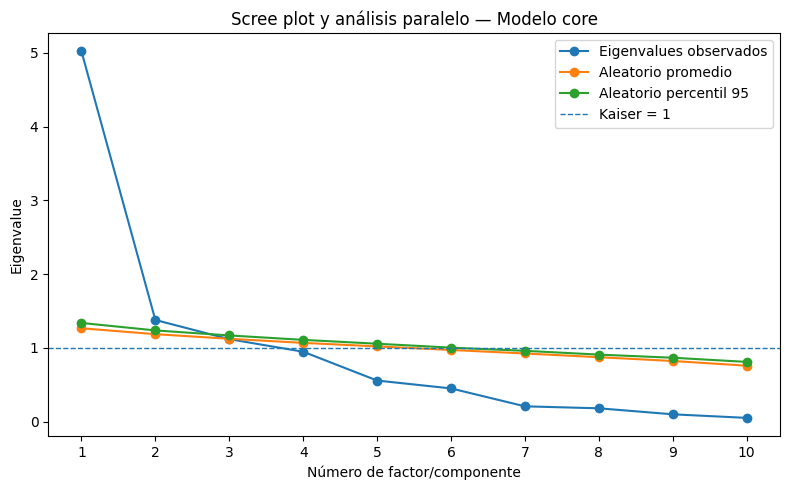

In [ ]:
X_core, _, _ = prepare_matrix(clean, CORE_AFFECT_COLS)
R_core = corr_matrix(X_core)
core_kmo = kmo_statistic(R_core)
core_bart = bartlett_sphericity(R_core, X_core.shape[0])
core_eig_obs, core_eig_mean, core_eig_p95, core_n_parallel = parallel_analysis(X_core, n_iter=500, random_state=42)
core_n_kaiser = int(np.sum(core_eig_obs > 1))

core_diag_pre = pd.DataFrame({
    "métrica": ["n observaciones", "n variables", "KMO", "Bartlett chi2", "Bartlett gl", "Bartlett p", "Kaiser eigenvalue > 1", "Análisis paralelo p95"],
    "valor": [X_core.shape[0], X_core.shape[1], core_kmo, core_bart[0], core_bart[1], core_bart[2], core_n_kaiser, core_n_parallel]
})
display(core_diag_pre)

eig_core_tbl = pd.DataFrame({
    "factor_posible": np.arange(1, len(core_eig_obs) + 1),
    "eigenvalue_observado": core_eig_obs,
    "eigenvalue_aleatorio_promedio": core_eig_mean,
    "eigenvalue_aleatorio_p95": core_eig_p95,
})
display(eig_core_tbl.round(3))

plot_scree(
    core_eig_obs, core_eig_mean, core_eig_p95,
    "Scree plot y análisis paralelo — Modelo core",
    "scree_parallel_core.png"
)

### Decisión de factores para el modelo core

El diagnóstico suele producir dos señales complementarias:

- El **análisis paralelo** tiende a ser más conservador y puede sugerir 2 factores principales.
- El **criterio de Kaiser** puede sugerir 3 factores.

Para documentar el proyecto se ajusta un **modelo core de 3 factores**, porque permite separar una dimensión inicial/basal de las dimensiones de prueba. Sin embargo, la lectura conservadora de 2 factores —valencia y activación— también se reporta como referencia.

,valor
modelo,core
n_observaciones,366
n_variables,10
n_factores_seleccionado,3
KMO,0.7394
Bartlett_chi2,2897.4012
Bartlett_gl,45.0000
Bartlett_p,0.0000
factores_Kaiser_eig_mayor_1,3
factores_analisis_paralelo_p95,2


Cargas factoriales del modelo core. Cargas |valor| >= 0.40 aparecen en negritas.


,F1,F2,F3
valence_inicio,0.116,0.403,0.680
arousal_inicio,0.319,0.102,0.905
valence_p1_before,0.315,0.742,0.122
arousal_p1_before,0.715,0.141,0.228
valence_p1_during,0.301,0.936,0.132
arousal_p1_during,0.933,0.290,0.209
valence_p1_after,0.197,0.849,0.167
arousal_p1_after,0.835,0.325,0.187
valence_final,0.043,0.345,0.123
arousal_final,0.319,0.117,0.328



Comunalidades aproximadas:


,variable,comunalidad,unicidad_aprox
5,arousal_p1_during,0.9990,0.0010
4,valence_p1_during,0.9830,0.0170
1,arousal_inicio,0.9310,0.0690
7,arousal_p1_after,0.8380,0.1620
6,valence_p1_after,0.7870,0.2130
2,valence_p1_before,0.6640,0.3360
0,valence_inicio,0.6380,0.3620
3,arousal_p1_before,0.5840,0.4160
9,arousal_final,0.2230,0.7770
8,valence_final,0.1360,0.8640


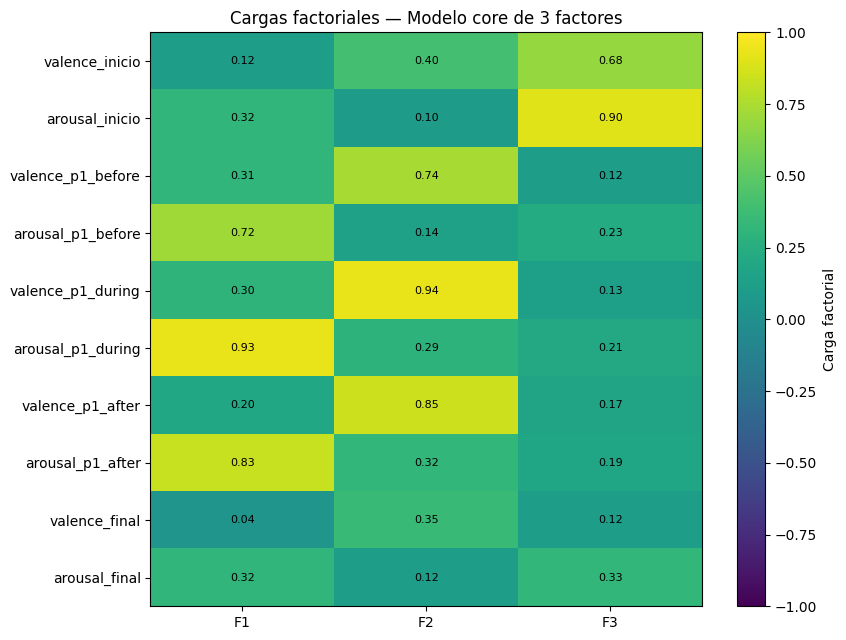

In [ ]:
CORE_N_FACTORS = 3
core_result = fit_efa(clean, CORE_AFFECT
2 	all_F3 	Valencia prueba 2 	valence_p2_before, valence_p2_during, valence_... 	Agrado/aversión durante la segunda prueba; ayu...
3 	all_F4 	Valencia prueba 1 	valence_p1_before, valence_p1_during, valence_... 	A_COLS, CORE_N_FACTORS, model_label="core")

core_diagnostics = pd.DataFrame([core_result["diagnostics"]])
display(core_diagnostics.T.rename(columns={0: "valor"}))

core_loadings = core_result["loadings"]
core_communalities = core_result["communalities"]
core_scores = core_result["scores"]

print("Cargas factoriales del modelo core. Cargas |valor| >= 0.40 aparecen en negritas.")
display(style_loadings(core_loadings, threshold=0.40))

print("\nComunalidades aproximadas:")
display(core_communalities.round(3))

# Guardar salidas
core_loadings.to_csv(OUTPUT_DIR / "loadings_core_3factores.csv")
core_communalities.to_csv(OUTPUT_DIR / "communalities_core_3factores.csv", index=False)
core_scores.to_csv(OUTPUT_DIR / "factor_scores_core_3factores.csv", index=False)
core_diagnostics.to_csv(OUTPUT_DIR / "diagnostics_core_3factores.csv", index=False)

loading_heatmap(core_loadings, "Cargas factoriales — Modelo core de 3 factores", "loadings_heatmap_core_3factores.png")

### Lectura conservadora de 2 factores para el modelo core

Esta versión ayuda a verificar si la estructura más estable coincide con el marco conceptual de **valencia** y **activación**.

Modelo core de 2 factores, útil como lectura conservadora:


,F1,F2
valence_inicio,0.241,0.461
arousal_inicio,0.485,0.183
valence_p1_before,0.324,0.749
arousal_p1_before,0.744,0.160
valence_p1_during,0.310,0.938
arousal_p1_during,0.951,0.303
valence_p1_after,0.215,0.862
arousal_p1_after,0.852,0.337
valence_final,0.061,0.359
arousal_final,0.375,0.147


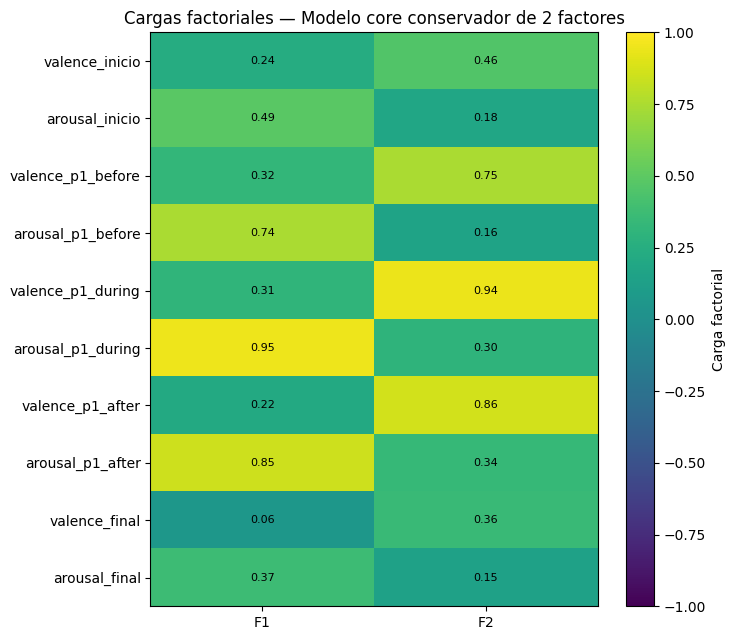

In [ ]:
core_2f = fit_efa(clean, CORE_AFFECT_COLS, 2, model_label="core2")
core_2f_loadings = core_2f["loadings"]
print("Modelo core de 2 factores, útil como lectura conservadora:")
display(style_loadings(core_2f_loadings, threshold=0.40))
core_2f_loadings.to_csv(OUTPUT_DIR / "loadings_core_2factores_conservador.csv")
loading_heatmap(core_2f_loadings, "Cargas factoriales — Modelo core conservador de 2 factores", "loadings_heatmap_core_2factores.png")

## 7. Interpretación del modelo core

La interpretación se basa en las variables con cargas altas. Los nombres de factores son etiquetas analíticas, no categorías definitivas.

In [ ]:
core_interpretation = pd.DataFrame({
    "factor": ["core_F1", "core_F2", "core_F3"],
    "nombre_sugerido": [
        "Activación durante prueba 1",
        "Valencia durante prueba 1",
        "Reactividad inicial / estado basal",
    ],
    "variables_que_más_cargan": [
        "arousal_p1_before, arousal_p1_during, arousal_p1_after",
        "valence_p1_before, valence_p1_during, valence_p1_after",
        "valence_inicio, arousal_inicio",
    ],
    "lectura_para_el_proyecto": [
        "Mide la intensidad de la reacción emocional durante la primera exposición observada.",
        "Mide el grado de agrado/aversión durante la primera exposición observada.",
        "Resume el punto de partida emocional antes de la prueba o al inicio del registro.",
    ],
})
display(core_interpretation)
core_interpretation.to_csv(OUTPUT_DIR / "interpretacion_factores_core.csv", index=False)

,factor,nombre_sugerido,variables_que_más_cargan,lectura_para_el_proyecto
0,core_F1,Activación durante prueba 1,"arousal_p1_before, arousal_p1_during, arousal_...",Mide la intensidad de la reacción emocional du...
1,core_F2,Valencia durante prueba 1,"valence_p1_before, valence_p1_during, valence_...",Mide el grado de agrado/aversión durante la pr...
2,core_F3,Reactividad inicial / estado basal,"valence_inicio, arousal_inicio",Resume el punto de partida emocional antes de ...


## 8. Validación externa con variables conductuales

Las variables `rechaza`, `llora`, `toca`, `prueba` y `consume` no se incluyen dentro del EFA principal porque son binarias/observacionales. En cambio, se usan para revisar si los factores se relacionan con comportamientos esperados.

Se calculan correlaciones de Spearman porque las variables conductuales no son continuas normales.

factor,core_F1,core_F2,core_F3
variable_externa,,,
consume,0.2150,0.0550,0.0140
dia_num,0.0610,0.0100,-0.0660
llora,0.0250,0.0980,0.1610
prueba,0.1360,0.0930,0.0590
rechaza,-0.1760,0.0360,-0.0290
toca,-0.2330,0.0540,-0.1770


,factor,variable_externa,n,rho_spearman,p_value
0,core_F1,rechaza,363,-0.1758,0.0008
1,core_F1,llora,362,0.0252,0.6332
2,core_F1,toca,363,-0.2325,0.0000
3,core_F1,prueba,363,0.1356,0.0097
4,core_F1,consume,363,0.2150,0.0000
5,core_F1,dia_num,365,0.0613,0.2428
6,core_F2,rechaza,363,0.0356,0.4985
7,core_F2,llora,362,0.0984,0.0614
8,core_F2,toca,363,0.0539,0.3059
9,core_F2,prueba,363,0.0932,0.0762


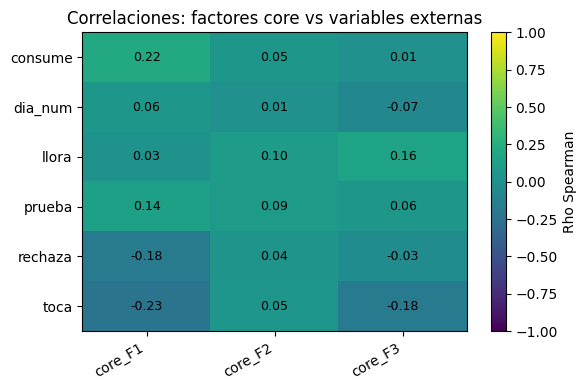

In [ ]:
def spearman_factor_correlations(scores_df, factor_cols, external_cols):
    rows = []
    for factor in factor_cols:
        for ext in external_cols:
            if ext not in scores_df.columns:
                continue
            tmp = scores_df[[factor, ext]].dropna()
            if tmp.shape[0] < 10 or tmp[ext].nunique() < 2:
                corr, pval = np.nan, np.nan
            else:
                corr, pval = stats.spearmanr(tmp[factor], tmp[ext])
            rows.append({
                "factor": factor,
                "variable_externa": ext,
                "n": tmp.shape[0],
                "rho_spearman": corr,
                "p_value": pval,
            })
    return pd.DataFrame(rows)

core_factor_cols = [c for c in core_scores.columns if c.startswith("core_F")]
external_cols = BEHAVIOR_COLS + ["dia_num"]
core_external_corr = spearman_factor_correlations(core_scores, core_factor_cols, external_cols)
display(core_external_corr.pivot(index="variable_externa", columns="factor", values="rho_spearman").round(3))
display(core_external_corr.round(4))
core_external_corr.to_csv(OUTPUT_DIR / "spearman_core_factores_vs_conducta.csv", index=False)

# Heatmap simple de correlaciones
corr_mat = core_external_corr.pivot(index="variable_externa", columns="factor", values="rho_spearman")
plt.figure(figsize=(6, 4))
plt.imshow(corr_mat.values, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Rho Spearman")
plt.xticks(np.arange(corr_mat.shape[1]), corr_mat.columns, rotation=30, ha="right")
plt.yticks(np.arange(corr_mat.shape[0]), corr_mat.index)
plt.title("Correlaciones: factores core vs variables externas")
for i in range(corr_mat.shape[0]):
    for j in range(corr_mat.shape[1]):
        value = corr_mat.values[i, j]
        plt.text(j, i, "" if pd.isna(value) else f"{value:.2f}", ha="center", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "correlaciones_core_factores_conducta.png", dpi=160, bbox_inches="tight")
plt.show()

In [ ]:
# Comparación descriptiva de scores por conducta binaria
factor_summary_by_behavior = []
for behavior in BEHAVIOR_COLS:
    if behavior not in core_scores.columns:
        continue
    for factor in core_factor_cols:
        for value, group in core_scores.dropna(subset=[behavior]).groupby(behavior):
            if value in [0, 1]:
                factor_summary_by_behavior.append({
                    "conducta": behavior,
                    "valor": int(value),
                    "factor": factor,
                    "n": group.shape[0],
                    "media_score": group[factor].mean(),
                    "mediana_score": group[factor].median(),
                    "desv_est_score": group[factor].std(),
                })

factor_summary_by_behavior = pd.DataFrame(factor_summary_by_behavior)
display(factor_summary_by_behavior.round(3))
factor_summary_by_behavior.to_csv(OUTPUT_DIR / "resumen_scores_por_conducta_core.csv", index=False)

,conducta,valor,factor,n,media_score,mediana_score,desv_est_score
0,rechaza,0,core_F1,202,0.1630,0.1490,1.0300
1,rechaza,1,core_F1,161,-0.2070,0.0540,0.9290
2,rechaza,0,core_F2,202,-0.0150,-0.2570,0.9990
3,rechaza,1,core_F2,161,0.0240,-0.2450,0.9910
4,rechaza,0,core_F3,202,0.0160,-0.0170,1.0010
5,rechaza,1,core_F3,161,-0.0170,-0.1480,0.9180
6,llora,0,core_F1,342,-0.0150,0.1160,1.0180
7,llora,1,core_F1,20,0.2060,0.0870,0.6830
8,llora,0,core_F2,342,-0.0420,-0.2510,0.9310
9,llora,1,core_F2,20,0.7470,-0.2460,1.6260


## 9. Visualización de scores factoriales core

Los scores factoriales permiten ubicar cada observación en un espacio reducido. Esto puede usarse posteriormente como entrada o lente para Mapper/TDA.

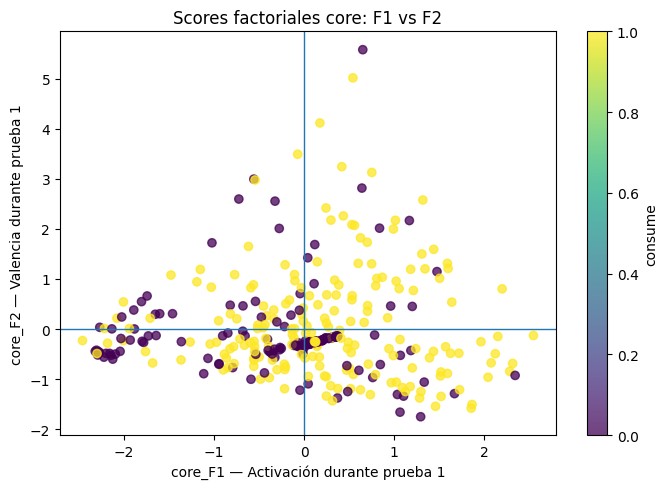

,dia_num,core_F1,core_F2,core_F3
0,1.0000,-0.0209,-0.1291,-0.1301
1,2.0000,-0.1768,0.2519,0.1942
2,3.0000,-0.3220,0.2021,0.0869
3,4.0000,-0.2941,0.0885,0.0921
4,5.0000,0.3556,0.0720,-0.3276


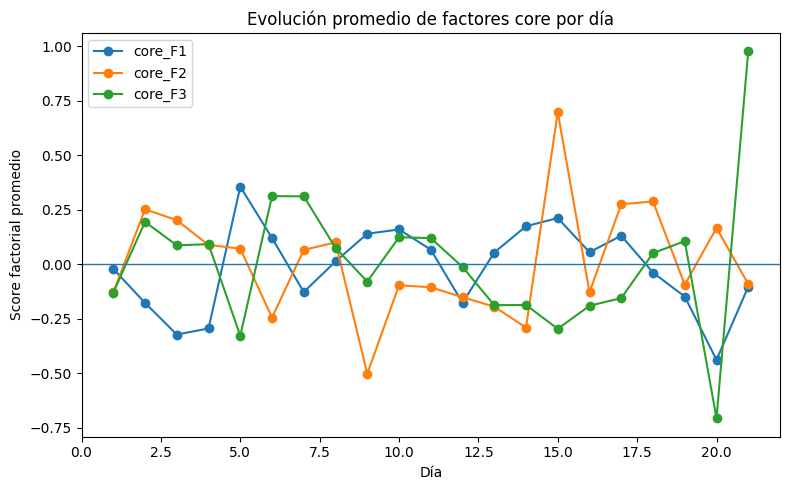

In [ ]:
# Scatter F1 vs F2; si consume existe, se usa como variable de referencia visual.
plot_df = core_scores.copy()
plt.figure(figsize=(7, 5))
if "consume" in plot_df.columns and plot_df["consume"].notna().sum() > 0:
    sc = plt.scatter(plot_df["core_F1"], plot_df["core_F2"], c=plot_df["consume"], alpha=0.75)
    plt.colorbar(sc, label="consume")
else:
    plt.scatter(plot_df["core_F1"], plot_df["core_F2"], alpha=0.75)
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("core_F1 — Activación durante prueba 1")
plt.ylabel("core_F2 — Valencia durante prueba 1")
plt.title("Scores factoriales core: F1 vs F2")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "scatter_scores_core_F1_F2.png", dpi=160, bbox_inches="tight")
plt.show()

# Evolución promedio por día
if plot_df["dia_num"].notna().sum() > 0:
    trend = plot_df.groupby("dia_num")[core_factor_cols].mean().reset_index()
    display(trend.head())
    plt.figure(figsize=(8, 5))
    for f in core_factor_cols:
        plt.plot(trend["dia_num"], trend[f], marker="o", label=f)
    plt.axhline(0, linewidth=1)
    plt.xlabel("Día")
    plt.ylabel("Score factorial promedio")
    plt.title("Evolución promedio de factores core por día")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "tendencia_factores_core_por_dia.png", dpi=160, bbox_inches="tight")
    plt.show()

## 10. Modelo ampliado/sensibilidad con variables de prueba 2

Este análisis incluye las variables `p2`. Sirve para revisar si la estructura factorial se separa por momento de medición: prueba 1 vs prueba 2. Debe interpretarse con cautela porque las variables `p2` tienen más datos faltantes y el resultado depende más de la imputación.

,métrica,valor
0,n observaciones,366.0000
1,n variables,16.0000
2,KMO,0.7502
3,Bartlett chi2,5268.4473
4,Bartlett gl,120.0000
5,Bartlett p,0.0000
6,Kaiser eigenvalue > 1,4.0000
7,Análisis paralelo p95,3.0000


,factor_posible,eigenvalue_observado,eigenvalue_aleatorio_promedio,eigenvalue_aleatorio_p95
0,1,6.2850,1.3770,1.4530
1,2,2.7440,1.2960,1.3520
2,3,1.6490,1.2350,1.2800
3,4,1.1160,1.1800,1.2220
4,5,0.9920,1.1330,1.1680
5,6,0.8990,1.0890,1.1250
6,7,0.5650,1.0500,1.0850
7,8,0.4810,1.0080,1.0410
8,9,0.4010,0.9690,1.0010
9,10,0.2200,0.9300,0.9610


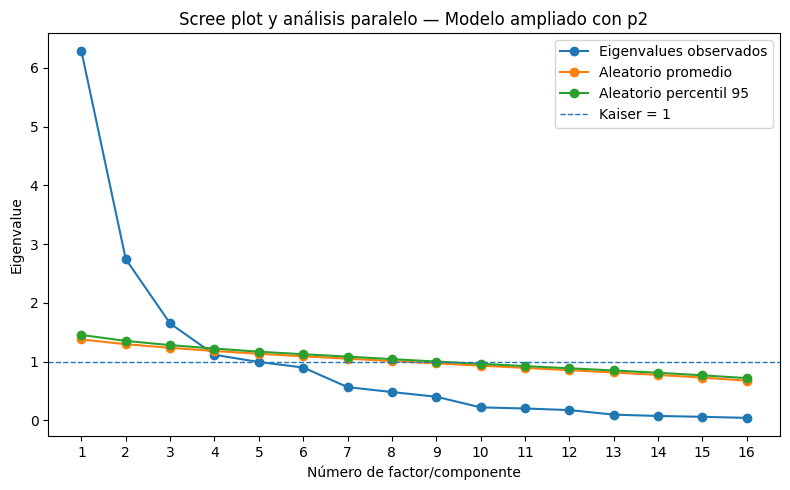

In [ ]:
X_all, _, _ = prepare_matrix(clean, ALL_AFFECT_COLS)
R_all = corr_matrix(X_all)
all_kmo = kmo_statistic(R_all)
all_bart = bartlett_sphericity(R_all, X_all.shape[0])
all_eig_obs, all_eig_mean, all_eig_p95, all_n_parallel = parallel_analysis(X_all, n_iter=500, random_state=42)
all_n_kaiser = int(np.sum(all_eig_obs > 1))

all_diag_pre = pd.DataFrame({
    "métrica": ["n observaciones", "n variables", "KMO", "Bartlett chi2", "Bartlett gl", "Bartlett p", "Kaiser eigenvalue > 1", "Análisis paralelo p95"],
    "valor": [X_all.shape[0], X_all.shape[1], all_kmo, all_bart[0], all_bart[1], all_bart[2], all_n_kaiser, all_n_parallel]
})
display(all_diag_pre)

eig_all_tbl = pd.DataFrame({
    "factor_posible": np.arange(1, len(all_eig_obs) + 1),
    "eigenvalue_observado": all_eig_obs,
    "eigenvalue_aleatorio_promedio": all_eig_mean,
    "eigenvalue_aleatorio_p95": all_eig_p95,
})
display(eig_all_tbl.round(3))

plot_scree(
    all_eig_obs, all_eig_mean, all_eig_p95,
    "Scree plot y análisis paralelo — Modelo ampliado con p2",
    "scree_parallel_all_affect.png"
)

Cargas factoriales del modelo ampliado. Cargas |valor| >= 0.40 aparecen en negritas.


,F1,F2,F3,F4
valence_inicio,0.082,0.094,0.233,0.449
arousal_inicio,0.119,0.047,0.472,0.174
valence_p1_before,0.103,0.151,0.316,0.730
valence_p1_during,0.083,0.188,0.308,0.915
valence_p1_after,0.081,0.160,0.210,0.846
valence_p2_before,0.409,0.681,0.115,0.103
valence_p2_during,0.281,0.942,0.064,0.174
valence_p2_after,0.175,0.856,0.042,0.172
arousal_p1_before,0.131,0.061,0.732,0.146
arousal_p1_during,0.157,0.067,0.942,0.288



Comunalidades aproximadas:


,variable,comunalidad,unicidad_aprox
12,arousal_p2_during,1.0000,0.0000
6,valence_p2_during,1.0000,0.0000
9,arousal_p1_during,0.9990,0.0010
3,valence_p1_during,0.9750,0.0250
10,arousal_p1_after,0.8380,0.1620
13,arousal_p2_after,0.8300,0.1700
7,valence_p2_after,0.7950,0.2050
4,valence_p1_after,0.7920,0.2080
11,arousal_p2_before,0.6880,0.3120
2,valence_p1_before,0.6660,0.3340


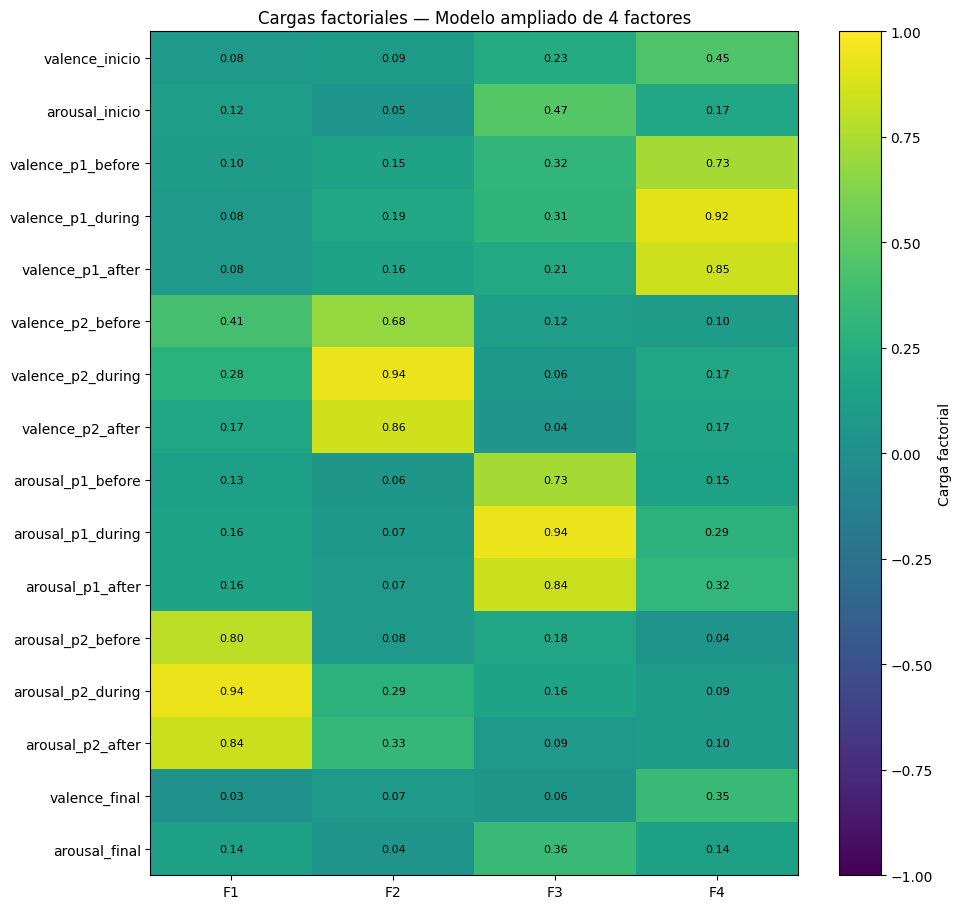

In [ ]:
ALL_N_FACTORS = 4
all_result = fit_efa(clean, ALL_AFFECT_COLS, ALL_N_FACTORS, model_label="all")

all_diagnostics = pd.DataFrame([all_result["diagnostics"]])
all_loadings = all_result["loadings"]
all_communalities = all_result["communalities"]
all_scores = all_result["scores"]

print("Cargas factoriales del modelo ampliado. Cargas |valor| >= 0.40 aparecen en negritas.")
display(style_loadings(all_loadings, threshold=0.40))
print("\nComunalidades aproximadas:")
display(all_communalities.round(3))

all_loadings.to_csv(OUTPUT_DIR / "loadings_all_affect_4factores.csv")
all_communalities.to_csv(OUTPUT_DIR / "communalities_all_affect_4factores.csv", index=False)
all_scores.to_csv(OUTPUT_DIR / "factor_scores_all_affect_4factores.csv", index=False)
all_diagnostics.to_csv(OUTPUT_DIR / "diagnostics_all_affect_4factores.csv", index=False)

loading_heatmap(all_loadings, "Cargas factoriales — Modelo ampliado de 4 factores", "loadings_heatmap_all_affect_4factores.png")